:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_00_conceptual_intro.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

(glm_intro_background)=
# Generalized Linear Models: An Introduction

Before we dive into using NeMoS, you might wonder: why model at all? Why not
 just make a bunch of tuning curves and submit to *Science*? Modeling is
 helpful because:

- The tuning curve reflects the correlation between neuronal spiking and
  feature of interest, but activity might be driven by some other highly
  correlated input (after all, [correlation does not imply
  causation](https://xkcd.com/552/)). How do you identify what's driving
  activity?

- Your model instantiates specific hypotheses about the system (e.g., that
  only instantaneous current matters for firing rate) and makes specific
  quantitative predictions that can be used to compare among hypotheses.

:::{attention}
We are not claiming that the GLM will allow you to uniquely determine
causation! Like any statistical model or method, the GLM will not solve
causation for you (causation being a notoriously difficult problem in
science), but it will allow you to see the effect of adding and removing
different inputs on the predicted firing rate, which can facilitate
causal inferences. For more reading on causation and explanation in
neuroscience, the work of [Carl Craver](https://philosophy.wustl.edu/people/carl-f-craver)
is a good place to start.
:::

Now that we've convinced you that modeling is worthwhile, let's get started!
How should we begin?

When modeling, it's generally a good idea to start simple and add complexity
as needed. Simple models are:

- Easier to understand, so you can more easily reason through why a model is
  capturing or not capturing some feature of your data.

- Easier to fit, so you can more quickly see how you did.

- Surprisingly powerful, so you might not actually need all the bells and
  whistles you expected.

Therefore, let's start with the simplest possible model: the only input is the
instantaneous value of some input. This is equivalent to saying that the only
input influencing the firing rate of this neuron at time $t$ is the input it
received at that same time. As neuroscientists, we know this isn't true, but
given the data exploration we did above, it looks like a reasonable starting
place. We can always build in more complications later.

### GLM components

The Generalized Linear Model in neuroscience can also be thought of as a LNP
model: a linear-nonlinear-Poisson model.

<figure markdown>
<!-- note that the src here has an extra ../ compared to other images, necessary when specifying path directly in html -->
<img src="../_static/lnp_model.svg" style="width: 100%", alt="Linear-Non Linear-Poisson illustration."/>
<figcaption>LNP model schematic. Modified from Pillow et al., 2008.</figcaption>
</figure>

The model receives some input and then:

- sends it through a linear filter or transformation of some sort.
- passes that through a nonlinearity to get the *firing rate*.
- uses the firing rate as the mean of a Poisson process to generate *spikes*.

Let's step through each of those in turn.

Our input feature(s) are first passed through a linear transformation, which
rescales and shifts the input: $ \boldsymbol{W X} + \boldsymbol{c} $. In the one-dimensional case, as
in this example, this is equivalent to scaling it by a constant and adding an
intercept.

:::{note}
In geometry, this is more correctly referred to as an [affine
transformation](https://en.wikipedia.org/wiki/Affine_transformation),
which includes translations, scaling, and rotations. *Linear*
transformations are the subset of affine transformations that do not
include translations.

In neuroscience, "linear" is the more common term, and we will use it
throughout.
:::

This means that, in the 1d case, we have two knobs to transform the input: we
can make it bigger or smaller, or we can shift it up or down. That is, we
compute:

$$
L(x(t)) = w x(t) + c \tag{1}
$$

for some value of $w$ and $c$. Let's visualize some possible transformations
that our model can make with three cartoon neurons:

In [2]:
import matplotlib.pyplot as plt

# first import things
import numpy as np
import pynapple as nap

import nemos as nmo

# some helper plotting functions
from nemos import _documentation_utils as doc_plots

# configure plots some
plt.style.use(nmo.styles.plot_style)

to simplify things, we will look at three simple LNP neuron models as
described above, working through each step of the transform. First, we will
plot the linear transformation of the input x:

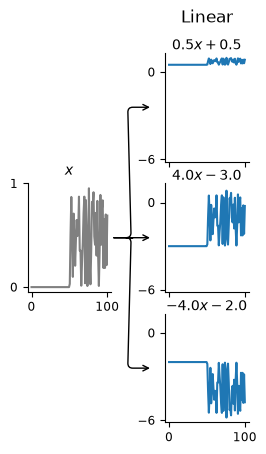

In [3]:
weights = np.asarray([.5, 4, -4])
intercepts = np.asarray([.5, -3, -2])

# make a step function with some noise riding on top
input_feature = np.zeros(100)
input_feature[50:] = 1
input_feature *= np.random.rand(100)
input_feature = nap.Tsd(np.linspace(0, 100, 100), input_feature)

fig = doc_plots.lnp_schematic(input_feature, weights, intercepts)

With these linear transformations, we see that we can stretch or shrink the
input and move its baseline up or down. Remember that the goal of this
model is to predict the firing rate of the neuron. Thus, changing what
happens when there's zero input is equivalent to changing the baseline firing
rate of the neuron, so that's how we should think about the intercept.

However, if this is meant to be the firing rate, there's something odd ---
the output of the linear transformation is often negative, but firing rates
have to be non-negative! That's what the nonlinearity handles: making sure our
firing rate is always positive. We can visualize this second stage of the LNP model
by adding the `plot_nonlinear` keyword to our `lnp_schematic()` plotting function:

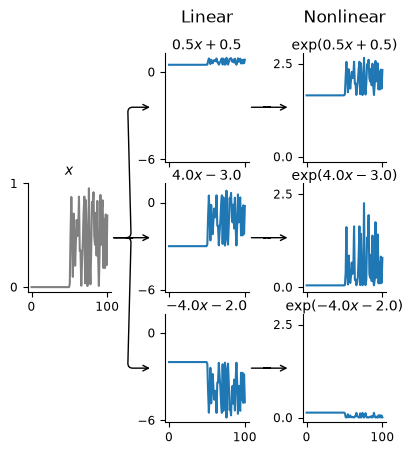

In [4]:
fig = doc_plots.lnp_schematic(input_feature, weights, intercepts,
                              plot_nonlinear=True)

:::{note}
In NeMoS, the non-linearity is kept fixed. We default to the exponential,
but a small number of other choices, such as soft-plus, are allowed. The
allowed choices guarantee both the non-negativity constraint described
above, as well as convexity, i.e. a single optimal solution. In
principle, one could choose a more complex non-linearity, but convexity
is not guaranteed in general.
:::

Specifically, our firing rate is:

$$
\lambda (t) = \exp (L(x(t)) = \exp (w x(t) + c) \tag{2}
$$

We can see that the output of the nonlinear transformation is always
positive, though note that the y-values have changed drastically.

Now we're ready to look at the third step of the LNP model, and see what
the generated spikes spikes look like!

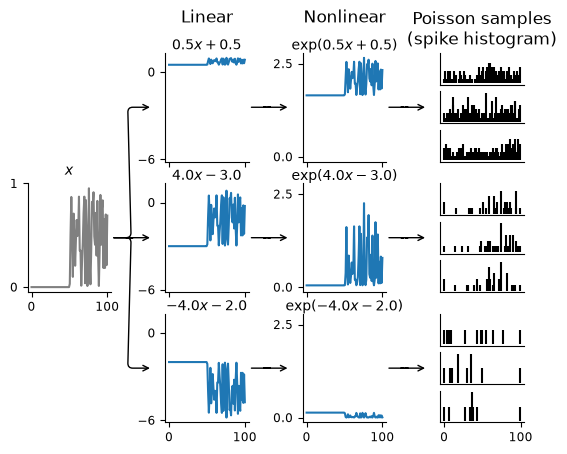

In [5]:
# mkdocs_gallery_thumbnail_number = 3
fig = doc_plots.lnp_schematic(input_feature, weights, intercepts,
                              plot_nonlinear=True, plot_spikes=True)

Remember, spiking is a stochastic process. That means that a given firing
rate can give rise to a variety of different spike trains; the plot above
shows three possibilities for each neuron. Each spike train is a sample from
a Poisson process with the mean equal to the firing rate, i.e., output of
the linear-nonlinear parts of the model.

Given that this is a stochastic process that could produce an infinite number
of possible spike trains, how do we compare our model against the single
observed spike train we have? We use the _log-likelihood_. This quantifies how
likely it is to observe the given spike train for the computed firing rate:
if $y(t)$ is the spike counts and $\lambda(t)$ the firing rate, the equation
for the log-likelihood is

$$ \sum_t \log P(y(t) | \lambda(t)) = \sum_t y(t) \log(\lambda(t)) -
\lambda(t) - \log (y(t)!)\tag{3}$$

Note that this last $\log(y(t)!)$ term does not depend on $\lambda(t)$ and
thus is independent of the model, so it is normally ignored.

$$ \sum_t \log P(y(t) | \lambda(t)) \propto \sum_t y(t) \log(\lambda(t)) -
\lambda(t))\tag{4}$$

This is the objective function of the GLM model: we are trying to find the
firing rate that maximizes the likelihood of the observed spike train.

:::{note}

In NeMoS, the log-likelihood can be computed directly by calling the
`score` method, passing the predictors and the counts. The method first
computes the rate $\lambda(t)$ using (2) and then the likelihood using
(4). This method is used under the hood during optimization.

:::



## More general GLMs
So far, we have focused on the relatively simple LNP model of spike generation, which is a special case of a GLM. The LNP model has some known shortcomings[$^{[1]}$](#ref-1). For instance, LNP ignores things like refactory periods and other history-dependent features of spiking in a neuron. As we will show in other demos, such _spike history filters_ can be built into GLMs to give more accurate results. We will also show how, if you have recordings from a large _population_ of neurons simultaneously, you can build connections between the neurons into the GLM in the form of _coupling filters_. This can help answer the degree to which activity is driven primarily by the input X, or by network influences in the population.

## References
(ref-1)=
[1] [Pillow, JW, Shlens, J, Paninski, L, Sher, A,  Litke, AM, Chichilnisky, EJ, Simoncelli, EP (2008),  "Spatio-temporal correlations and visual signalling in a complete neuronal population." Nature 454: 995-9.](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2684455/)